In [6]:
import numpy as np
import os
import csv
import networkx as nx
import random
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

import generate_graph
import play_greedy

In [7]:
EMBEDDING_FILE = "data/embeddings.pkl"
K_VALUES = range(1,10)
N_VALUES = range(1,10)
NUM_GAMES = 100

def run_experiment(out_path, algorithm_type='probabilistic'):
    print(f"Loading vectors from {EMBEDDING_FILE}...")
    words, vectors = generate_graph.load_vectors(EMBEDDING_FILE)
    embeddings_dict = {w: v for w, v in zip(words, vectors)}    

    print(f"Starting sweep for Algorithm: {algorithm_type}")
    print(f"Logging to: {out_path}")
    
    if not os.path.exists(out_path):
        with open(out_path, mode='w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["algorithm", "k_nn", "n_long", "start", "target", "success", "pth_len", "opt_len", "diff"])

    for k_val in K_VALUES:
        for n_val in N_VALUES:
            if k_val == 0 and n_val == 0:
                continue
            G = generate_graph.build_small_world(words, vectors, k_val, n_val, algorithm=algorithm_type)
            nodes = list(G.nodes())
            
            results_buffer = []
            
            for _ in tqdm(range(NUM_GAMES), desc="Simulating"):
                # A. Find valid start/target pair
                while True:
                    start, target = random.sample(nodes, 2)
                    try:
                        # Only pick pairs that actually have a path
                        opt_path = nx.shortest_path(G, start, target)
                        opt_len = len(opt_path) - 1
                        if opt_len >= 2: break
                    except nx.NetworkXNoPath:
                        continue
                
                # B. Play Game
                success, ai_path = play_greedy.play_game(G, embeddings_dict, start, target)
                
                # C. Stats
                if success:
                    ai_len = len(ai_path) - 1
                    diff = ai_len - opt_len
                else:
                    ai_len = -1
                    diff = -1
                
                results_buffer.append([algorithm_type, k_val, n_val, start, target, success, ai_len, opt_len, diff])
            
            with open(out_path, mode='a', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                writer.writerows(results_buffer)

In [ ]:
run_experiment("data/greedy_results_prob.csv", "probabilistic")
run_experiment("data/greedy_results_knn.csv", "random")

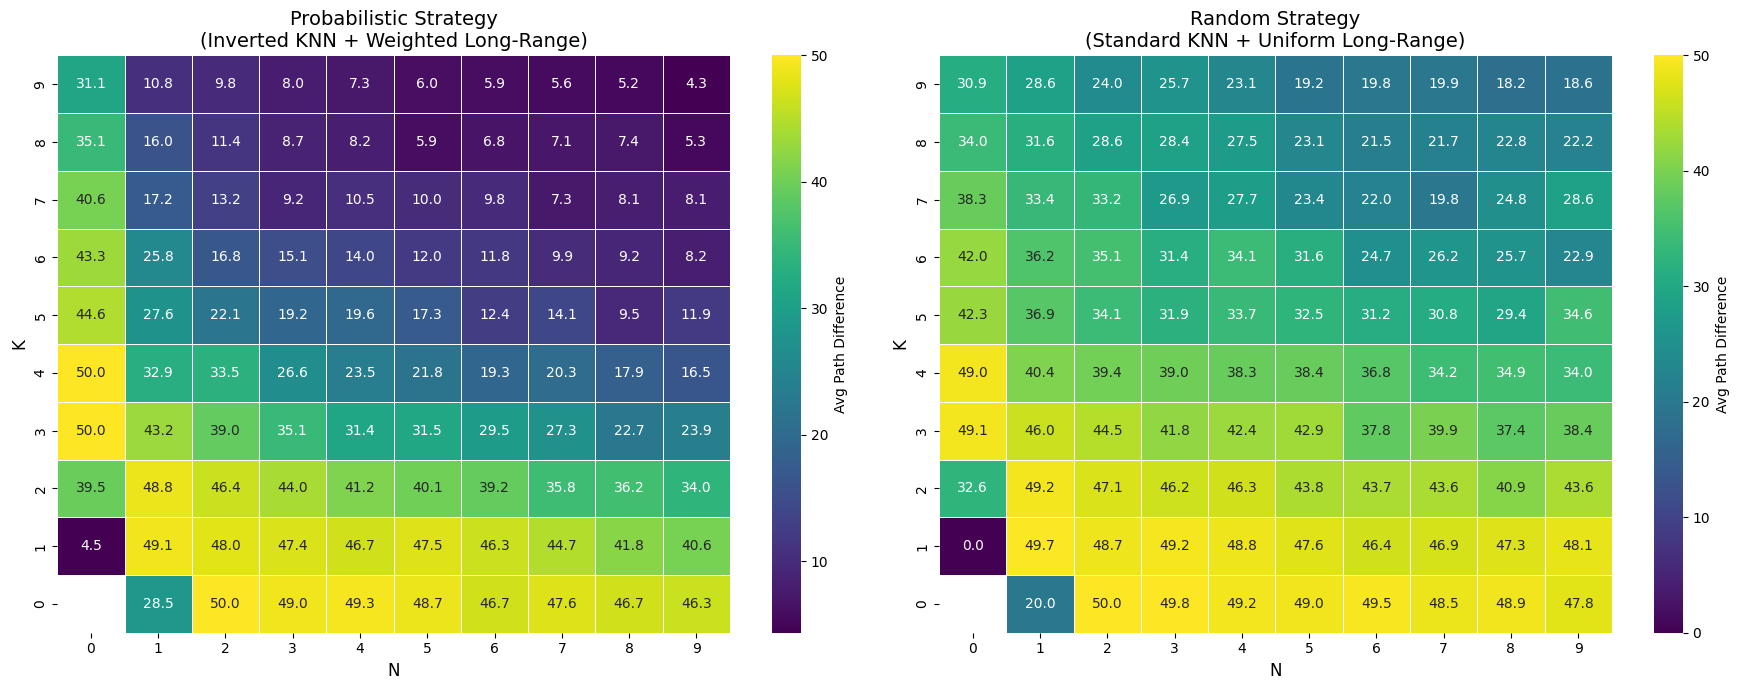

In [8]:
df_prob = pd.read_csv("data/greedy_results_prob.csv")
df_knn = pd.read_csv("data/greedy_results_knn.csv")

def prepare_heatmap_data(df):
    df = df.copy()
    df = df[df['k_nn'] < 10]
    df = df[df['n_long'] < 10]

    df['diff_adj'] = df['diff'].replace(-1, 50)
    
    heatmap_data = df.groupby(['k_nn', 'n_long'])['diff_adj'].mean().reset_index()
    
    pivot_table = heatmap_data.pivot(index='k_nn', columns='n_long', values='diff_adj')
    
    pivot_table = pivot_table.sort_index(ascending=False)
    
    return pivot_table

pivot_prob = prepare_heatmap_data(df_prob)
pivot_knn = prepare_heatmap_data(df_knn)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

heatmap_args = {
    'cmap': 'viridis',
    'annot': True,
    'fmt': '.1f',
    'linewidths': 0.5,
    'cbar_kws': {'label': 'Avg Path Difference'}
}

# Heatmap 1: Probabilistic
sns.heatmap(pivot_prob, ax=axes[0], **heatmap_args)
axes[0].set_title('Probabilistic Strategy\n(Inverted KNN + Weighted Long-Range)', fontsize=14)
axes[0].set_ylabel('K', fontsize=12)
axes[0].set_xlabel('N', fontsize=12)

# Heatmap 2: Random
sns.heatmap(pivot_knn, ax=axes[1], **heatmap_args)
axes[1].set_title('Random Strategy\n(Standard KNN + Uniform Long-Range)', fontsize=14)
axes[1].set_ylabel('K', fontsize=12)
axes[1].set_xlabel('N', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
human_results = pd.read_csv("data/human_results.csv")
human_results['diff'] = human_results['diff'].replace(-1, 50)
plot_data = human_results.groupby('k_nn')['diff'].mean()
plot_errors = human_results.groupby('k_nn')['diff'].sem()

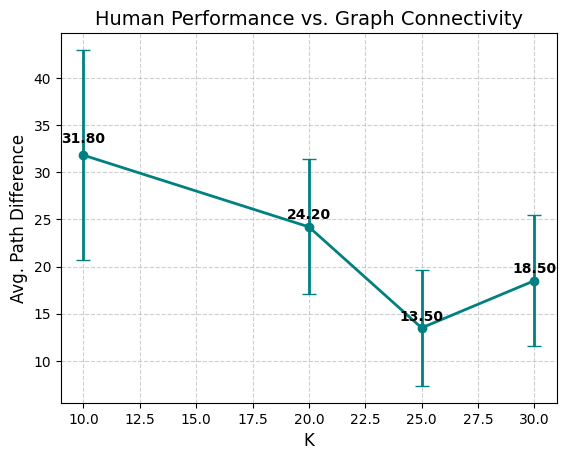

In [ ]:
plt.errorbar(x=plot_data.index, 
             y=plot_data.values, 
             yerr=plot_errors.values, 
             fmt='-o',
             color='teal',
             linewidth=2, 
             markersize=6,
             capsize=5,
             label='Mean Diff')

for x, y in zip(plot_data.index, plot_data.values):
    plt.text(x, y + 0.15 + (plot_errors[x] * 0.1),
             f'{y:.2f}',
             ha='center',
             fontweight='bold', 
             color='black')

plt.title('Human Performance vs. Graph Connectivity', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.ylabel('Avg. Path Difference', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()